In [2]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

from utils import apply_filter, apply_DCR, BB, weighted_avg_and_std


colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

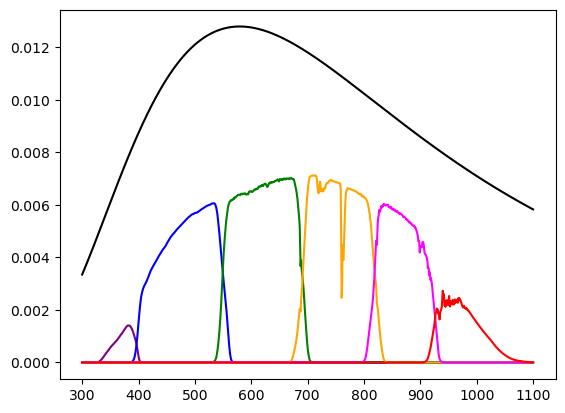

In [3]:
source_temperature = 5000 #K
reference_temperature = 4500 #K

wave = np.linspace(300, 1100, 1000)  # nm
BB_sed = BB(wave, source_temperature, scale = 1e-8)
ref_sed = BB(wave, reference_temperature, scale = 1e-8)

plt.plot(wave, BB_sed, 'k-')

BB_filtered = {}
ref_filtered = {}
for band in 'ugrizy':
    filtered_sed = apply_filter(wave, BB_sed, band)
    BB_filtered[band] = filtered_sed

    filtered_ref = apply_filter(wave, ref_sed, band)
    ref_filtered[band] = filtered_ref

    plt.plot(wave, BB_filtered[band], color = colors[band], label = band)



Text(0, 0.5, 'Second moment shift (arcsec$^2$)')

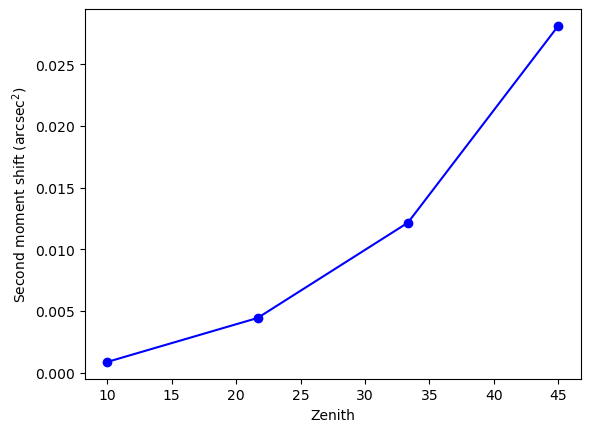

In [4]:
zeniths = np.linspace(10, 45, 4)

DCR1 = {} #first relative moment shifts (mean)
DCR2 = {} #second moment shifts (variance)

for band in 'ugrizy':
    DCR1[band] = np.array([])
    DCR2[band] = np.array([])

pressure=69.328
temperature=293.15
H2O_pressure=1.067

for zenith in zeniths:
    refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean, R_stdev = weighted_avg_and_std(refraction_angles, filtered_refracted_data) #arcsec


    refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean_ref, R_stdev_ref = weighted_avg_and_std(refraction_angles, filtered_refracted_data_ref) #arcsec


    for band in 'ugrizy':
        DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
        DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)


plt.plot(zeniths, DCR2['g'], 'b-o', label = 'g')
plt.xlabel('Zenith')
plt.ylabel('Second moment shift (arcsec$^2$)')

0.24000000000000005
1.1512601791080939


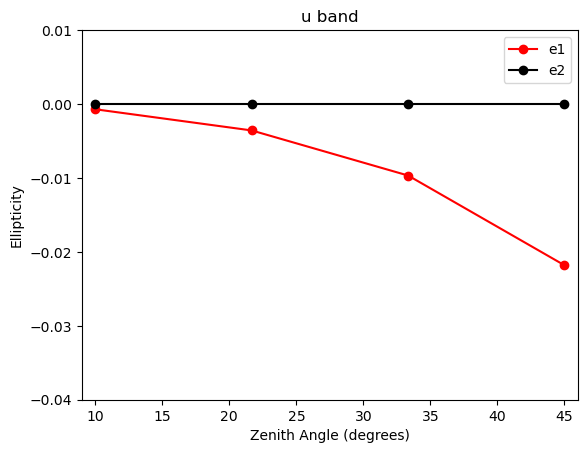

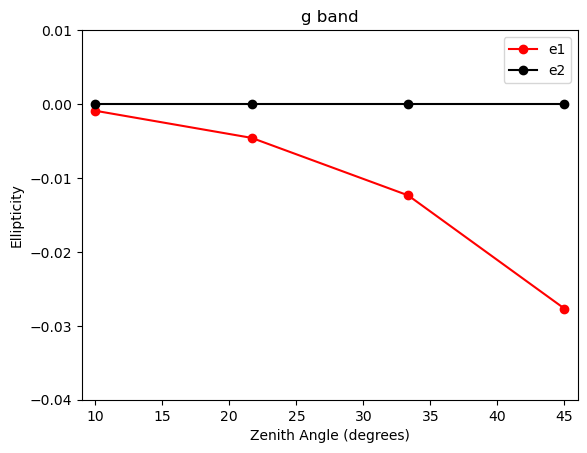

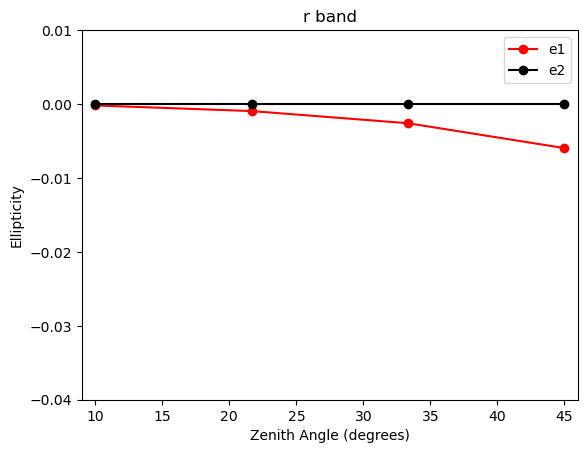

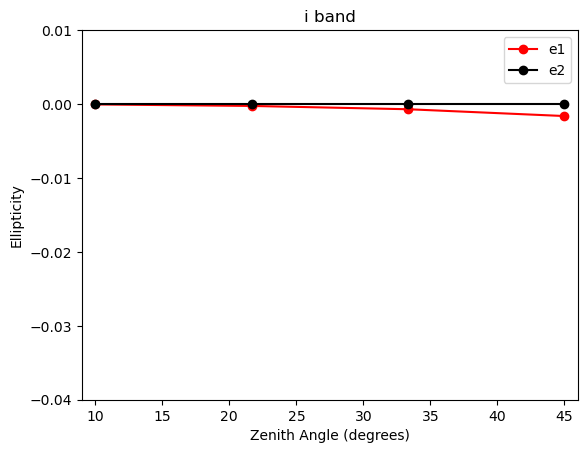

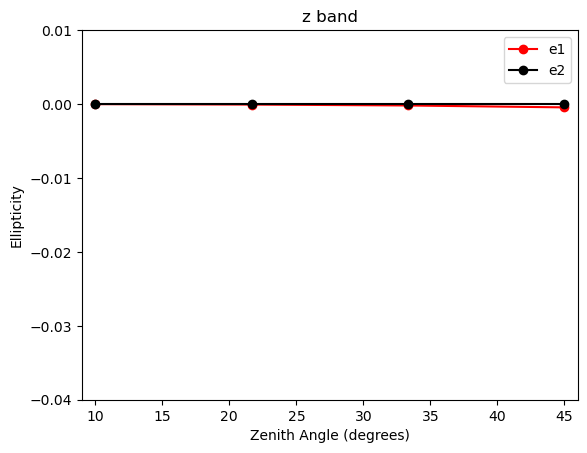

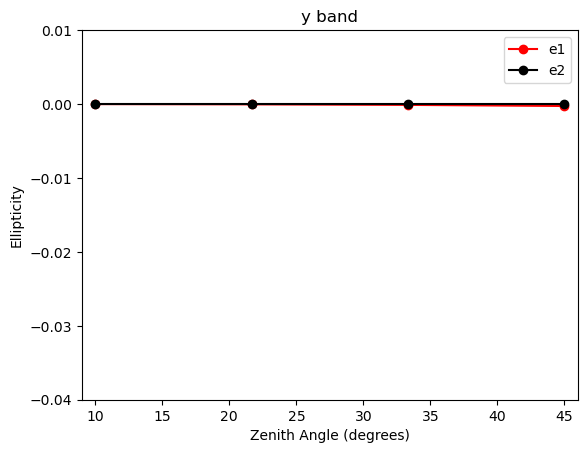

In [5]:
shape_xx = 6 * (0.2**2) #arcsec^2
shape_yy = 6 * (0.2**2) #arcsec^2
shape_xy = 0.0 * (0.2**2) #arcsec^2

print(shape_xx)

print(np.sqrt(shape_xx)*2.35)

for band in 'ugrizy':
    Ixx = np.ones(len(DCR2[band])) * shape_xx
    Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]
    Ixy = np.ones(len(DCR2[band])) * shape_xy

    e1 = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
    e2 = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

    plt.plot(zeniths, e1, 'r-o', label = 'e1')
    plt.plot(zeniths, e2, 'k-o', label = 'e2')
    plt.xlabel('Zenith Angle (degrees)')
    plt.ylabel(f'Ellipticity')
    plt.title(f'{band} band')
    plt.ylim(-0.04, 0.01)
    plt.xlim(9, 46)
    plt.legend()
    plt.show()
    plt.close()


In [24]:
# create function to generate these quickly

def BB_dcr(source_temperature, reference_temperature, zeniths, shape_xx, shape_yy, shape_xy, plot = False, noise = None, return_mags = False):

    wave = np.linspace(300, 1100, 1000)  # nm
    BB_sed = BB(wave, source_temperature, scale = 1e-8)
    ref_sed = BB(wave, reference_temperature, scale = 1e-8)

    BB_filtered = {}
    ref_filtered = {}
    if return_mags:
        mags = {}

    for band in 'ugrizy':
        filtered_sed = apply_filter(wave, BB_sed, band)
        BB_filtered[band] = filtered_sed

        filtered_ref = apply_filter(wave, ref_sed, band)
        ref_filtered[band] = filtered_ref
        if return_mags:
            mags[band] = -2.5 * np.log10(np.trapezoid(filtered_sed, wave))

    
    DCR1 = {} #first relative moment shifts (mean)
    DCR2 = {} #second moment shifts (variance)

    for band in 'ugrizy':
        DCR1[band] = np.array([])
        DCR2[band] = np.array([])

    pressure=69.328
    temperature=293.15
    H2O_pressure=1.067

    for zenith in zeniths:
        refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean, R_stdev = weighted_avg_and_std(refraction_angles, filtered_refracted_data) #arcsec

        refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean_ref, R_stdev_ref = weighted_avg_and_std(refraction_angles, filtered_refracted_data_ref) #arcsec

        for band in 'ugrizy':
            DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
            DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)

    e1 = {}
    e2 = {}

    if plot:
        fig, ax = plt.subplots(3, 2, figsize = (12,10), sharey = True)
        
    for i, band in enumerate('ugrizy'):
        Ixx = np.ones(len(DCR2[band])) * shape_xx
        Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]
        Ixy = np.ones(len(DCR2[band])) * shape_xy

        e1[band] = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
        e2[band] = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

        if plot:
            ax[i//2, i%2].plot(zeniths, e1[band], 'r-o', label = f'e1 {band}')
            ax[i//2, i%2].plot(zeniths, e2[band], 'k-o', label = f'e2 {band}')
            ax[i//2, i%2].legend()

    if return_mags:
        return DCR1, DCR2, e1, e2, mags
    else:
        return DCR1, DCR2, e1, e2

# zeniths = np.linspace(10, 45, 10)
# scrap = BB_dcr(7000, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot = True)

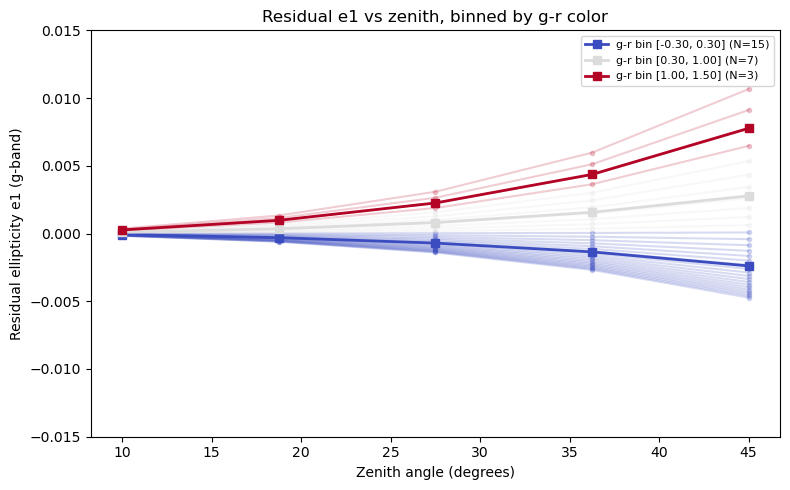

In [60]:
source_temperatures = [4000, 6000, 8000, 15000]
source_temperatures = np.linspace(2500, 9000, 30)
source_temperatures = np.flip(source_temperatures)
zeniths = np.linspace(10, 45, 5)

DCR1_base, DCR2_base, e1_base, e2_base = BB_dcr(5000, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot = False)

# Collect g-r colors and residual e1 for each SED
gr_colors = []
resid_e1_list = []
resid_e1s = {}

for source_temperature in source_temperatures:
    DCR1, DCR2, e1, e2, mags = BB_dcr(source_temperature, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot = False, return_mags = True)
    gr = mags['g'] - mags['r']
    resid = e1['g'] - e1_base['g']
    resid_e1s[gr] = resid
    gr_colors.append(gr)
    resid_e1_list.append(resid)

gr_colors = np.array(gr_colors)
resid_e1_arr = np.array(resid_e1_list)  # shape: (n_temps, n_zeniths)

# Define bins in g-r color
n_bins = 3
# bin_edges = np.linspace(gr_colors.min(), gr_colors.max(), n_bins + 1)
bin_edges = np.array([-0.3, 0.3, 1.0, 1.5])
n_bins = len(bin_edges) - 1
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Assign each SED to a bin and compute averages
cmap = plt.cm.coolwarm
fig, ax = plt.subplots(figsize=(8, 5))

for i, (gr, resid) in enumerate(zip(gr_colors, resid_e1_arr)):
    # Determine which bin this SED falls in
    bin_idx = np.clip(np.digitize(gr, bin_edges) - 1, 0, n_bins - 1)
    color = cmap(bin_idx / (n_bins - 1))
    ax.plot(zeniths, resid, '-o', color=color, alpha=0.2, markersize=3)

# Plot binned averages
for b in range(n_bins):
    mask = (gr_colors >= bin_edges[b]) & (gr_colors < bin_edges[b + 1])
    # Include right edge in the last bin
    if b == n_bins - 1:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors <= bin_edges[b + 1])
    if mask.sum() == 0:
        continue
    avg_resid = resid_e1_arr[mask].mean(axis=0)
    color = cmap(b / (n_bins - 1))
    ax.plot(zeniths, avg_resid, '-s', color=color, alpha = 1.0,  linewidth=2, markersize=6,
            label=f'g-r bin [{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}] (N={mask.sum()})')

ax.set_xlabel('Zenith angle (degrees)')
ax.set_ylabel('Residual ellipticity e1 (g-band)')
ax.legend(fontsize=8)
ax.set_title('Residual e1 vs zenith, binned by g-r color')
ax.set_ylim(-0.015, 0.015)
plt.tight_layout()
plt.show()

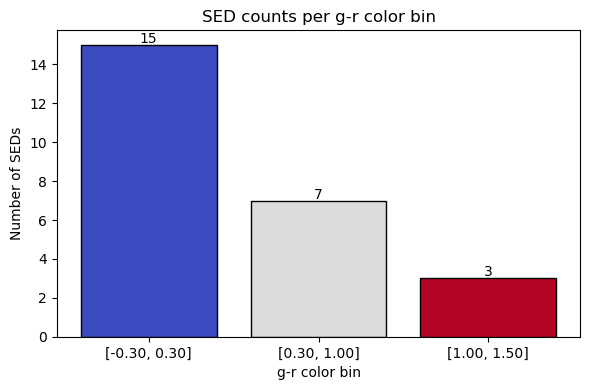

In [61]:
# Histogram of counts per g-r color bin
counts = []
labels = []
bar_colors = []
cmap = plt.cm.coolwarm

for b in range(n_bins):
    if b == n_bins - 1:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors <= bin_edges[b + 1])
    else:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors < bin_edges[b + 1])
    counts.append(mask.sum())
    labels.append(f'[{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}]')
    bar_colors.append(cmap(b / (n_bins - 1)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(n_bins), counts, color=bar_colors, edgecolor='k')
ax.set_xticks(range(n_bins))
ax.set_xticklabels(labels)
ax.set_xlabel('g-r color bin')
ax.set_ylabel('Number of SEDs')
ax.set_title('SED counts per g-r color bin')
for i, c in enumerate(counts):
    ax.text(i, c + 0.1, str(c), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
np.logspace(np.log10(3000), np.log10(9000), 30)

array([3000.        , 3115.82969353, 3236.13155969, 3361.07826861,
       3490.84915721, 3625.63048655, 3765.61570925, 3911.0057471 ,
       4062.00927946, 4218.84304277, 4381.73214167, 4550.91037203,
       4726.62055659, 4909.11489342, 5098.65531795, 5295.51387891,
       5499.9731288 , 5712.32652944, 5932.87887319, 6161.94672039,
       6399.85885378, 6646.95675033, 6903.59507143, 7170.14217188,
       7446.98062865, 7734.50778996, 8033.1363456 , 8343.29491925,
       8665.42868376, 9000.        ])